## <p style="text-align: right;"> &#9989; Put your name here</p>

##### CMSE 201: Quiz 4 (TEMPLATE Fall 2024)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**100 points**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (40 points)

&#9989;&nbsp; **Question 1 (30 points)**: In this question, you're going to think about how one could build a general model to study chemical reactions. Chemical reactions can be irreversible (the reaction only goes in one direction) or reversible. We will be looking at the case of a reversible reaction (https://en.wikipedia.org/wiki/Reversible_reaction) as a function of time.  We can model this system with the following equations:

$$ \frac{dA}{dt} = -2ABy + 2Cx $$
$$ \frac{dB}{dt} = -2ABy + 2Cx $$
$$ \frac{dC}{dt} = -4Cx +4ABy $$

where $A$ is one chemical reactant, $B$ is the second chemical reactant, and $C$ is the product. Since we are looking at chemical reactions, we assume will use **seconds** as our unit of time, $t$. This means that, for example, $t = 2$ would be _2 seconds_. 

Solve this reversible chemical reaction using `solve_ivp` where $x = 0.2$ and $y = 0.004$ . Assuming the following initial conditions:

* $A(0) = 150$
* $B(0) = 200$
* $C(0) = 0$ 

Evolve the model for 3 seconds using a timestep of $\Delta t = 0.01$ seconds.

**Code you need to write to solve this problem**:
* A function that takes in a set of time values as well as the current values for $A$, $B$, and $C$ and **returns** the derivatives for each variable, $\frac{dA}{dt}$, $\frac{dB}{dt}$, and $\frac{dC}{dt}$. This would be your "derivatives" function that `solve_ivp` needs.
* A set of variables for storing your initial conditions, $A_0$, $B_0$, and $C_0$, set to the correct initial values.
* A variable that stores all the times for which you want to solve the system of ODEs, you can generate these times using `np.arange()`. The times should match the time range and timestep size specified above.
* Code that calls `solve_ivp` using all of the appropriate arguments and stores the result. 
* Code that unpacks the solution so that you can plot it.

**Note**: you will need the "`args`" argument for `solve_ivp` for this case because the model parameters need to be specified. 

In [1]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


In [6]:
### ANSWER ###

# Import needed modules
from scipy.integrate import solve_ivp
import numpy as np

# Define the derivatives function
def derivs(t, vals, x,y):
    A, B, C = vals
    dAdt = -2*A*B*y + 2*C*x
    dBdt =-2*A*B*y + 2*C*x
    dCdt = -4*C*x + 4*A*B*y
    return dAdt, dBdt, dCdt

# Solve the system
A0 = 150
B0 = 200
C0 = 0
ICs = [A0, B0, C0]
t = np.arange(0, 3, 0.01)
sol = solve_ivp(derivs, (t[0], t[-1]),ICs, t_eval=t,args=[0.2,0.004])
A = sol.y[0,:]
B = sol.y[1,:]
C = sol.y[2,:]
print(C)

[  0.           4.71492472   9.26483571  13.65710821  17.89914155
  21.99826612  25.96004031  29.78978156  33.49264137  37.07360536
  40.53749324  43.88895879  47.13248991  50.27240858  53.31287086
  56.25786691  59.111221    61.87659147  64.55747075  67.15718538
  69.67889598  72.12559726  74.50011804  76.80512934  79.04352489
  81.21757158  83.3291418   85.38007235  87.37216451  89.30718404
  91.18686114  93.01289046  94.78693113  96.51060672  98.18550529
  99.81317932 101.39514579 102.93288611 104.42784615 105.88143627
 107.29503125 108.66997036 110.00755732 111.3090603  112.57571194
 113.80870935 115.00921407 116.17835212 117.31721399 118.4268546
 119.50829336 120.56251412 121.59037478 122.59242725 123.56923856
 124.52137281 125.44938802 126.35383612 127.23526294 128.09420823
 128.93120563 129.74678271 130.54146094 131.3157557  132.07017626
 132.80522584 133.52140153 134.21919435 134.89908922 135.56156497
 136.20709433 136.83614397 137.44917442 138.04664016 138.62898957
 139.196664

&#9989;&nbsp; **Question 2 (10 points)**:
Now that you have a solution to the model, make a single plot that displays the evolution of all three variables, A, B, and C as a function time. Each line should be a different color and your plot should contain a $x$-axis label, a $y$-axis label, and a legend.

If all goes well, you should end up with something that looks like this:

<img src="https://i.ibb.co/Rgfyz7M/Quiz4-007.png" alt="Quiz4 image showing three distinct lines. One green line from left to right starts out below the other two then increases and levels off above the other two. An orange line startes above the other two then decreases and levels off between the green and blue line. The blue line starts below the orange line but about the green line decreases and levels off below the green and orange line." border="0" width=500>

In [3]:
# put your code here

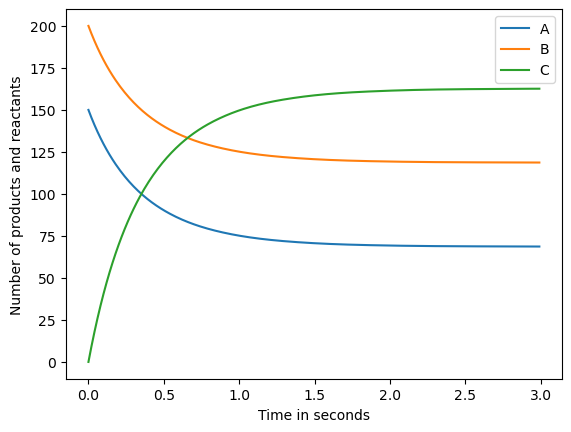

In [8]:
### ANSWER ###
# Import needed modules
import matplotlib.pyplot as plt

# In years
plt.figure(1)
plt.plot(t,A,label="A")
plt.plot(t,B,label="B")
plt.plot(t,C,label="C")
plt.xlabel("Time in seconds")
plt.ylabel("Number of products and reactants")
plt.legend()
#plt.savefig("Quiz4_007.png")

## Part 2: Data Visualization (45 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **three** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 30 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. Make sure you indicate which three visualizations you have selected!

&#9989;&nbsp; **Question 2 (5 points per visualization - 15 points total)**: Grade each visualization you chose using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (2 Points)** 
2. **No wasted space (1 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

### Visualizations to Choose From


**Visualization 1**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Picture2.jpg?raw=true">

**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true">

**Visualization 3**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/badGraphic.png?raw=true">

**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (7).png?raw=true">

**Visualization 5**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (2).png?raw=true">

**Visualization 6**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true">

**Visualization 7**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (9).png?raw=true">

**Visualization 8**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/whimsical_squid.png?raw=true">

### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations and add your favorite bad visualizations!



**QUESTION 1 RESPONSES HERE**

**QUESTION 2 RESPONSES HERE**

**Last question (5 points)**: What is one thing you learned from this class and genuinely plan to use in your future? This does not have to be course content related. It could be what you learned from group work or some type of social interaction you had.

Answer here: